## Setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv("data/synthetic_student_week_data.csv")

# Stored as 0/1 in the CSV; cast to bool for readable filtering
df["treatment"] = df["treatment"].astype(bool)
df["post_period"] = df["post_period"].astype(bool)

display(df.head())
print("Rows:", len(df), " Students:", df["student_id"].nunique())

,student_id,grade_level,ses_band,baseline_score,baseline_engagement,treatment,week,post_period,weekly_active_days,assignments_completed,engagement_index,assessment_score
0,1,6,mid,72.786471,3.15067,False,1,False,3,2,2.5,69.946917
1,1,6,mid,72.786471,3.15067,False,3,False,2,2,2.0,71.182093
2,1,6,mid,72.786471,3.15067,False,4,False,4,5,4.5,70.695706
3,1,6,mid,72.786471,3.15067,False,5,False,4,1,2.5,72.494023
4,1,6,mid,72.786471,3.15067,False,6,False,3,2,2.5,72.593499


Rows: 90761  Students: 8000


## Data checks

In [3]:
# Columns required for the analysis
baseline_cols = ["treatment", "grade_level", "ses_band", "baseline_score", "baseline_engagement"]
assert {"student_id", "week", "post_period", *baseline_cols}.issubset(df.columns)

# Baseline attributes are complete and constant within each student
assert df[baseline_cols].notna().all().all()
assert (df.groupby("student_id")[baseline_cols].nunique() == 1).all().all()

## Student-level baseline table

In [4]:
# One row per student; baseline attributes are constant, so the first week represents the student
stu = (df.sort_values(["student_id", "week"])
         .groupby("student_id", as_index=False)
         .first()[["student_id", *baseline_cols]])

## Baseline balance

In [5]:
# Baseline score and engagement by arm
balance_numeric = (stu.groupby("treatment")[["baseline_score", "baseline_engagement"]]
                     .agg(["mean", "std", "count"])
                     .round(3))

# Share of each arm in each SES band and grade level (columns sum to 1)
ses_mix = (pd.crosstab(stu["ses_band"], stu["treatment"], normalize="columns")
             .rename(columns={False: "control_share", True: "treat_share"})
             .round(3))

grade_mix = (pd.crosstab(stu["grade_level"], stu["treatment"], normalize="columns")
               .rename(columns={False: "control_share", True: "treat_share"})
               .round(3))

print("Numeric balance:")
display(balance_numeric)
print("SES mix:")
display(ses_mix)
print("Grade mix:")
display(grade_mix)

Numeric balance:


baseline_score               baseline_engagement             
                    mean     std count                mean    std count
treatment                                                              
False             70.212   9.824  4005               3.527  1.039  4005
True              70.220  10.109  3995               3.509  1.044  3995

SES mix:


treatment,control_share,treat_share
ses_band,,
high,0.241,0.241
low,0.303,0.303
mid,0.456,0.457


Grade mix:


treatment,control_share,treat_share
grade_level,,
6,0.145,0.145
7,0.147,0.146
8,0.142,0.142
9,0.151,0.151
10,0.133,0.133
11,0.146,0.146
12,0.137,0.137


Treatment and control are balanced at baseline: differences in mean baseline score (0.008 points) and engagement (0.018 days) are under 0.02 SD, and SES and grade-level shares match within 0.001. Because treatment was assigned in the data-generation step, this confirms the assignment worked as intended rather than serving as independent evidence of comparability.

## Pre-period outcome levels

In [6]:
outcomes = ["weekly_active_days", "assignments_completed", "engagement_index", "assessment_score"]

# Pre-intervention weeks only
pre = df[~df["post_period"]]

# Unrounded means by arm; rounding happens after the difference so it doesn't compound
pre_means_raw = pre.groupby("treatment")[outcomes].mean()

pre_means = (pre_means_raw
               .rename(index={False: "control_pre", True: "treat_pre"})
               .round(3))

pre_diff = ((pre_means_raw.loc[True] - pre_means_raw.loc[False])
              .to_frame("treat_minus_control_pre")
              .round(3))

display(pre_means)
display(pre_diff)

,weekly_active_days,assignments_completed,engagement_index,assessment_score
treatment,,,,
control_pre,3.315,2.382,2.848,70.664
treat_pre,3.296,2.365,2.830,70.670


,treat_minus_control_pre
weekly_active_days,-0.019
assignments_completed,-0.017
engagement_index,-0.018
assessment_score,0.006


Pre-period outcome levels are nearly identical across arms (all gaps under 0.02 on engagement measures and 0.006 points on assessment score). The small negative gaps on engagement measures mirror the slightly lower baseline engagement in the treatment group. DiD differences out stable level gaps, so parallel pre-period trends, tested below, are the more relevant check.

## Pre-period trends

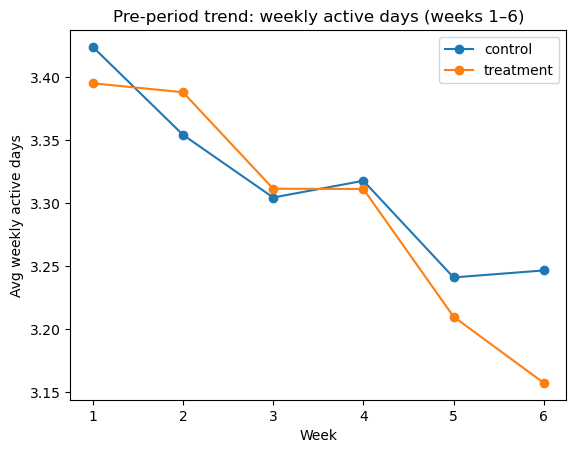

In [7]:
# Primary outcome, matching the headline DiD estimate
metric = "weekly_active_days"

trend_pre = pre.groupby(["week", "treatment"], as_index=False)[metric].mean()

for is_treated, g in trend_pre.groupby("treatment"):
    plt.plot(g["week"], g[metric], marker="o", label="treatment" if is_treated else "control")

first_wk, last_wk = pre["week"].min(), pre["week"].max()
plt.title(f"Pre-period trend: weekly active days (weeks {first_wk}–{last_wk})")
plt.xlabel("Week")
plt.ylabel("Avg weekly active days")
plt.legend()
plt.show()

In [8]:
# Weeks re-indexed from 0, so the treatment coefficient is the gap at week 1
pre2 = pre.copy()
pre2["week_c"] = pre2["week"] - pre2["week"].min()

# Parallel-trends test: the treatment:week_c coefficient is the difference in weekly slopes
model = smf.ols(f"{metric} ~ treatment + week_c + treatment:week_c", data=pre2).fit(cov_type="HC3")
print(model.summary().tables[1])

                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    3.4015      0.023    149.242      0.000       3.357       3.446
treatment[T.True]            0.0173      0.032      0.536      0.592      -0.046       0.080
week_c                      -0.0347      0.008     -4.615      0.000      -0.049      -0.020
treatment[T.True]:week_c    -0.0146      0.011     -1.375      0.169      -0.035       0.006


The treatment × week interaction is small and not statistically significant (−0.015 days/week, p = 0.17), so the test does not reject parallel pre-period trends. Because the data were generated with identical pre-period trends, this confirms the test behaves as expected rather than providing independent evidence. Standard errors are heteroskedasticity-robust (HC3) but not clustered by student.

## Placebo test

In [9]:
# Placebo cutoff at week 4 splits the six pre-period weeks evenly (1–3 vs. 4–6); no intervention occurred
pre3 = pre.copy()
pre3["placebo_post"] = pre3["week"] >= 4
pre3["treat_x_placebo"] = pre3["treatment"].astype(int) * pre3["placebo_post"].astype(int)

# treat_x_placebo is the placebo DiD estimate; it should be near zero
placebo = smf.ols(f"{metric} ~ treatment + placebo_post + treat_x_placebo", data=pre3).fit(cov_type="HC3")
print(placebo.summary().tables[1])

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.3611      0.018    184.323      0.000       3.325       3.397
treatment[T.True]        0.0038      0.026      0.148      0.883      -0.047       0.054
placebo_post[T.True]    -0.0926      0.026     -3.598      0.000      -0.143      -0.042
treat_x_placebo         -0.0462      0.036     -1.268      0.205      -0.118       0.025


A placebo DiD with a fake intervention at week 4 finds no significant effect (−0.046 days, p = 0.21, 95% CI [−0.118, 0.025]). The confidence interval excludes effects anywhere near the estimated treatment effect of 0.37, supporting the conclusion that the main estimate is not an artifact of pre-existing group differences. As with the pre-trend test, this is expected given how the data were generated.

## Experimental validation summary

Baseline characteristics (grade level, SES band, baseline assessment score, and baseline engagement) are balanced between treatment and control: differences in continuous measures are under 0.02 SD, and categorical shares match within 0.001, consistent with stratified random assignment.

Pre-period outcome levels are nearly identical across groups, and both groups decline at a similar rate across weeks 1–6. A regression test finds no significant difference in pre-period slopes (−0.015 days/week, p = 0.17). A placebo DiD with a fictitious intervention at week 4 finds no significant effect (−0.046 days, p = 0.21), and its confidence interval excludes effects near the estimated treatment effect of 0.37.

**Limitations.** The data are synthetic, and treatment and control were generated with identical pre-period trends, so these checks confirm the validation methods behave as expected rather than providing independent evidence that parallel trends would hold in real data. Standard errors are heteroskedasticity-robust (HC3) but not clustered by student.